# GCV Contraction

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.optimize import minimize_scalar

## Data generation functions

In [32]:
def spiked_covariance(D):
    """
    Spiked-type covariance eigenvalues.

    Args:
        D: the number of parameters in the data matrix

    Returns:
        Sigma: the covariance matrix
    """
    x = np.linspace(-3, 3, D)
    eigenvalues = norm.pdf(x)
    eigenvalues = eigenvalues / eigenvalues.max()
    Sigma = np.diag(eigenvalues)
    return Sigma

def bulk_covariance(D):
    """
    Bulk-type covariance eigenvalues

    Args:
        D: the number of parameters in the data matrix

    Returns:
        Sigma: the covariance matrix
    """

    j = np.arange(1, D + 1)
    eigenvalues = (D - j + 1) / D
    Sigma = np.diag(eigenvalues)

    return Sigma

def generate_X(N, D, Sigma, rng):
    """
    Generates a random mean-centered X from a multivariate normal distribution.

    Args:
        N: the number of observations.
        D: the number of parameters.
        Sigma: the covariance matrix of the data matrix
            X with shape DxD.
        rng: A NumPy random number generator

    Returns:
        A matrix X of the shape NxD (N rows, D columns).
    """
    mu = np.zeros(D)
    X = rng.multivariate_normal(mean=mu, cov=Sigma, size=N)
    return X - X.mean(axis=0)


def generate_Y(X, N, theta, epsilon, rng):
    """
    Generates a random mean-centered y from a standard normal distribution.

    Args:
        X: the data matrix with shape NxD.
        N: the number of observations.
        theta: the true parameter vector.
        epsilon: the noise amplitude.
        rng: A NumPy random number generator

    Returns:
        A column vector y of the shape Nx1 (N rows, 1 column).
    """
    z = (rng.standard_normal(size=N))[:, np.newaxis]
    y = X @ theta + epsilon * z
    return y - y.mean(axis=0)

## GCV functions and stuff

\begin{equation}
    A(\lambda) = \left[
    \displaystyle\sum_{j=1}^m
    \frac{\lambda^2 a_j^2}{n(\sigma_j^2+\lambda)^2}
    +\displaystyle\sum_{j=m+1}^n\frac{a_j^2}{n}
    \right]
    \left[
    \displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2}{(\sigma_j^2+\lambda)^2}
    \right]
\end{equation}

\begin{equation}
    B(\lambda) = \displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2 a_j^2}{(\sigma_j^2+\lambda)^3} \left[1-\dfrac{1}{n}\displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2}{\sigma_j^2+\lambda}\right]
\end{equation}

\begin{equation}
    A'(\lambda) = \left[\frac{2\lambda}{n} \sum_{j = 1}^m \frac{\sigma_j^2 a_j^2}{(\sigma_j^2 + \lambda)^3}
    \right]
    \left[
    \displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2}{(\sigma_j^2+\lambda)^2}
    \right] -2 \left[
    \displaystyle\sum_{j=1}^m
    \frac{\lambda^2 a_j^2}{n(\sigma_j^2+\lambda)^2}
    +\displaystyle\sum_{j=m+1}^n\frac{a_j^2}{n}
    \right]
    \left[
    \displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2}{(\sigma_j^2+\lambda)^3}
    \right]
\end{equation}

\begin{equation}
    B'(\lambda) = -3\left[\displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2 a_j^2}{(\sigma_j^2+\lambda)^4} \right]\left[1-\dfrac{1}{n}\displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2}{\sigma_j^2+\lambda}\right] + \left[\displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2 a_j^2}{(\sigma_j^2+\lambda)^3} \right]\left[\dfrac{1}{n}\displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2}{(\sigma_j^2+\lambda)^2}\right].
\end{equation}

In [33]:
def A(lam, n, a, singular_values):
    a = np.asarray(a, dtype=float).reshape(-1)
    s2 = np.asarray(singular_values, dtype=float)**2
    m = len(s2)
    d = s2 + lam

    residual = (
        np.sum(lam**2 * a[:m]**2 / d**2)
        + np.sum(a[m:]**2)
    ) / n

    return residual * np.sum(s2 / d**2)


def B(lam, n, a, singular_values):
    a = np.asarray(a, dtype=float).reshape(-1)
    s2 = np.asarray(singular_values, dtype=float)**2
    m = len(s2)
    d = s2 + lam

    weighted_sum = np.sum(s2 * a[:m]**2 / d**3)
    factor = 1 - np.sum(s2 / d) / n

    return weighted_sum * factor


def A_prime(lam, n, a, singular_values):
    a = np.asarray(a, dtype=float).reshape(-1)
    s2 = np.asarray(singular_values, dtype=float)**2
    m = len(s2)
    d = s2 + lam

    residual = (
        np.sum(lam**2 * a[:m]**2 / d**2)
        + np.sum(a[m:]**2)
    ) / n
    residual_prime = (2 * lam / n) * np.sum(
        s2 * a[:m]**2 / d**3
    )

    return (
        residual_prime * np.sum(s2 / d**2)
        - 2 * residual * np.sum(s2 / d**3)
    )


def B_prime(lam, n, a, singular_values):
    a = np.asarray(a, dtype=float).reshape(-1)
    s2 = np.asarray(singular_values, dtype=float)**2
    m = len(s2)
    d = s2 + lam

    weighted_sum = np.sum(s2 * a[:m]**2 / d**3)
    weighted_sum_prime = -3 * np.sum(s2 * a[:m]**2 / d**4)
    factor = 1 - np.sum(s2 / d) / n
    factor_prime = np.sum(s2 / d**2) / n

    return weighted_sum_prime * factor + weighted_sum * factor_prime

\begin{equation}
    G'(\lambda) =
    \frac{
    \dfrac{2\lambda}{n}\displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2 a_j^2}{(\sigma_j^2+\lambda)^3}
    }{
    \left[1-\dfrac{1}{n}\displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2}{\sigma_j^2+\lambda}\right]^2
    }
    - \frac{
    \dfrac{2}{n}
    \left[
    \displaystyle\sum_{j=1}^m
    \frac{\lambda^2 a_j^2}{n(\sigma_j^2+\lambda)^2}
    +\displaystyle\sum_{j=m+1}^n\frac{a_j^2}{n}
    \right]
    \left[
    \displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2}{(\sigma_j^2+\lambda)^2}
    \right]
    }{
    \left[1-\dfrac{1}{n}\displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2}{\sigma_j^2+\lambda}\right]^3
    },
\end{equation}

In [34]:
def Gprime(lam, n, a, singular_values):
    a = np.asarray(a, dtype=float).reshape(-1)
    s2 = np.asarray(singular_values, dtype=float).reshape(-1)**2
    m = len(s2)
    d = s2 + lam

    residual = (
        np.sum(lam**2 * a[:m]**2 / d**2)
        + np.sum(a[m:n]**2)
    ) / n

    residual_prime = (2 * lam / n) * np.sum(
        s2 * a[:m]**2 / d**3
    )

    denominator = 1 - np.sum(s2 / d) / n

    return (
        residual_prime / denominator**2
        - (2 / n) * residual * np.sum(s2 / d**2) / denominator**3
    )

\begin{equation}
    \lambda 
    = \frac{\left[
    \displaystyle\sum_{j=1}^m
    \frac{\lambda^2 a_j^2}{n(\sigma_j^2+\lambda)^2}
    +\displaystyle\sum_{j=m+1}^n\frac{a_j^2}{n}
    \right]
    \left[
    \displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2}{(\sigma_j^2+\lambda)^2}
    \right]}{\displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2 a_j^2}{(\sigma_j^2+\lambda)^3} \left[1-\dfrac{1}{n}\displaystyle\sum_{j=1}^m
    \frac{\sigma_j^2}{\sigma_j^2+\lambda}\right]} = H(\lambda)
\end{equation}

\begin{equation}
    H'(\lambda) = \dfrac{A'(\lambda)}{B(\lambda)} - \dfrac{A(\lambda)B'(\lambda)}{(B(\lambda))^2}
\end{equation}

$$F(\lambda) = \frac{\lambda + H(\lambda)}{2}$$

$$F'(\lambda) = \dfrac{d}{d\lambda} \left[ \frac{\lambda + H(\lambda)}{2} \right] = \frac{1 + H'(\lambda)}{2}$$

\begin{equation}
    F'(\lambda) = \dfrac{1}{2} \left[1 +  \dfrac{A'(\lambda)}{B(\lambda)} - \dfrac{A(\lambda)B'(\lambda)}{(B(\lambda))^2} \right].
\end{equation}



In [35]:
def H(lam, n, a, singular_values):
    A_val = A(lam, n, a, singular_values)
    B_val = B(lam, n, a, singular_values)

    if B_val == 0:
        raise ZeroDivisionError("H is undefined when B(lam) = 0.")

    return A_val / B_val


def H_prime(lam, n, a, singular_values):
    A_val = A(lam, n, a, singular_values)
    B_val = B(lam, n, a, singular_values)

    if B_val == 0:
        raise ZeroDivisionError("H_prime is undefined when B(lam) = 0.")

    Ap_val = A_prime(lam, n, a, singular_values)
    Bp_val = B_prime(lam, n, a, singular_values)

    return Ap_val / B_val - A_val * Bp_val / B_val**2


def F(lam, n, a, singular_values):
    return (lam + H(lam, n, a, singular_values)) / 2


def F_prime(lam, n, a, singular_values):
    return (1 + H_prime(lam, n, a, singular_values)) / 2

## Initial test case

### Data generation

In [36]:
rng = np.random.default_rng(seed=77)

EPSILON = 10
ASPECT_RATIO = 1.2  # aspect ratio (d/N)
N = 1000 # observations
D = int(ASPECT_RATIO * N)  # parameters

In [37]:
theta = rng.standard_normal(size=D)[:, np.newaxis]
theta = theta / np.linalg.norm(theta)

covariance = spiked_covariance(D)
X = generate_X(N, D, covariance, rng)
y = generate_Y(X, N, theta, EPSILON, rng)

In [38]:
U, sigma, Vt = np.linalg.svd(X)
a = U.T @ y

In [39]:
def G(lam, n, a, singular_values):
    a = np.asarray(a).reshape(-1)
    s2 = np.asarray(singular_values) ** 2
    m = len(s2)

    numerator = (
        np.sum(lam**2 * a[:m]**2 / (s2 + lam)**2)
        + np.sum(a[m:]**2)
    ) / n

    denominator = (1 - np.sum(s2 / (s2 + lam)) / n)**2

    return numerator / denominator

In [40]:
result = minimize_scalar(G, args=(N, a, sigma))

gcv_infinity = np.sum(np.asarray(y).reshape(-1)**2) / N
tolerance = 1e-10 * max(1.0, abs(gcv_infinity))

if result.fun >= gcv_infinity - tolerance:
    optimal_lambda = np.inf
    optimal_gcv = gcv_infinity
    print("No finite improvement over infinite regularization detected.")
else:
    optimal_lambda = result.x
    optimal_gcv = result.fun

print("Optimal lambda:", optimal_lambda)
print("Optimal GCV:", optimal_gcv)

Optimal lambda: 14950.377647753196
Optimal GCV: 102.76380032039216


/var/folders/0h/tjr9j7295774lmdypmb_x8jc0000gn/T/ipykernel_27057/3066409043.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator


### Checking stationarity and minimum of GCV

In [41]:
print("G' of optimal lambda: ", Gprime(optimal_lambda, N, a, sigma))

G' of optimal lambda:  -1.1335723484016957e-12


In [42]:
diff = 1e-6 * optimal_lambda

print("Before the optimal lambda:", Gprime(optimal_lambda - diff, N, a, sigma))
print("After the optimal lambda: ", Gprime(optimal_lambda + diff, N, a, sigma))

Before the optimal lambda: -1.5467069844950915e-11
After the optimal lambda:  1.3199844971396868e-11


### Level set

In [43]:
def fprime_levelsets(lam_max, steps, n, a, singular_values):
    def g(lam):
        return abs(F_prime(lam, n, a, singular_values)) - 1

    lam_grid = np.linspace(0, lam_max, steps)[1:]
    f_values = np.array([g(lam) for lam in lam_grid])
    roots = []

    if not np.all(np.isfinite(f_values)):
        raise ValueError("Nonfinite derivative values in the search range.")

    for i in range(len(lam_grid) - 1):
        if f_values[i] == 0:
            roots.append(lam_grid[i])

        if f_values[i] * f_values[i + 1] < 0:
            roots.append(brentq(g, lam_grid[i], lam_grid[i + 1]))

    edges = sorted(set([0, *roots, lam_max]))

    endpoints = []
    for left, right in zip(edges[:-1], edges[1:]):
        if g((left + right) / 2) < 0:
            endpoints.extend([left, right])

    return endpoints

In [44]:
LAM_MAX = 10 * optimal_lambda
STEPS = 10000
print("Endpoints:", endpoints := fprime_levelsets(LAM_MAX, STEPS, N, a, sigma))

Endpoints: [2975.2452656292653, np.float64(149503.77647753197)]


In [45]:
lam_grid = np.linspace(0, LAM_MAX, 10000)[1:]
f_values = np.array([F_prime(lam, N, a, sigma) for lam in lam_grid])

print("Are all the values finite (T/F)?", np.all(np.isfinite(f_values)))
print("Minimum value of F':", np.min(f_values))
print("Maximum value of F':", np.max(f_values))

Are all the values finite (T/F)? True
Minimum value of F': 0.9811607098119564
Maximum value of F': 1.205834523640982


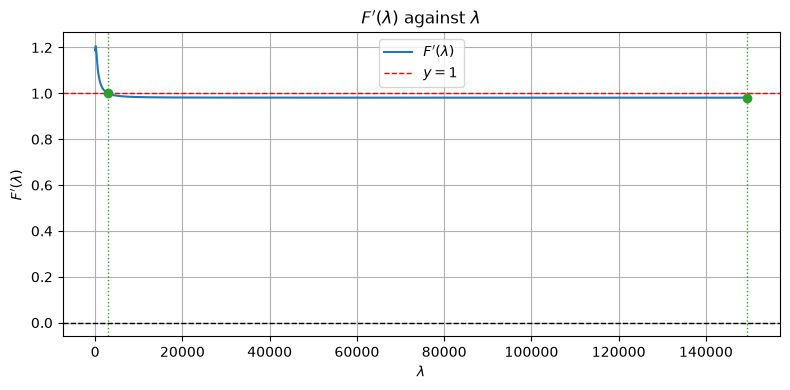

In [46]:
plt.figure(figsize=(8, 4))

plt.plot(lam_grid, f_values, label=r"$F'(\lambda)$")
plt.axhline(1, color="red", linestyle="--", linewidth=1, label="$y=1$")
plt.axhline(0, color="black", linestyle="--", linewidth=1)

for endpoint in endpoints:
    plt.axvline(endpoint, color="tab:green", linestyle=":", linewidth=1)
    plt.scatter(
        endpoint,
        F_prime(endpoint, N, a, sigma),
        color="tab:green",
        zorder=3
    )

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$F'(\lambda)$")
plt.title(r"$F'(\lambda)$ against $\lambda$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
def create_intervals(endpoints):
  if len(endpoints) % 2 != 0:
    raise ValueError("The list of endpoints must be even.")

  intervals = []
  for i in range(0, len(endpoints), 2):
    intervals.append((endpoints[i], endpoints[i + 1]))

  return intervals

print(intervals := create_intervals(endpoints))

[(2975.2452656292653, np.float64(149503.77647753197))]


### Fixed-point iteration

In [48]:
r = []

for interval in intervals:
    r_temp = (interval[1] - interval[0]) / 2
    r.append(r_temp)

if not intervals:
    raise ValueError("No contraction intervals detected in the search range.")

print("R_hat:", r_hat := min(r))

print("Number of estimated intervals:", w := int(np.ceil(LAM_MAX / (2 * r_hat))))

R_hat: 73264.26560595135
Number of estimated intervals: 2


In [49]:
def fixed_point_iteration(lam_0, iterations=1000, tol=1e-8):
    current_lam = float(lam_0)
    history = [current_lam]

    for _ in range(iterations):
        next_lam = F(current_lam, N, a, sigma)

        if not np.isfinite(next_lam) or next_lam <= 0:
            return current_lam, history, False

        history.append(next_lam)

        if abs(next_lam - current_lam) <= tol * (1 + abs(current_lam)):
            return next_lam, history, True

        current_lam = next_lam

    return current_lam, history, False

### Data analysis

In [50]:
interval_results = []

for i in range(w):
    left = i * 2 * r_hat
    right = (i + 1) * 2 * r_hat
    lam_0 = (left + right) / 2

    lam_star, lam_stars, converged = fixed_point_iteration(lam_0, iterations = 10000)

    if converged:
        gcv_value = G(lam_star, N, a, sigma)

        if np.isfinite(gcv_value):
            interval_results.append((lam_star, gcv_value))

if not interval_results:
    raise RuntimeError("None of the intervals converged.")

estimated_lambda, estimated_gcv = min(interval_results, key=lambda result: result[1])

print("Estimated lambda:", estimated_lambda)
print("Estimated GCV:", estimated_gcv)

print("Optimal lambda:", optimal_lambda)
print("Optimal GCV:", optimal_gcv)

print("Difference of lambdas (estimated - optimal):", (estimated_lambda - optimal_lambda))

Estimated lambda: 14950.38707283052
Estimated GCV: 102.7638003203922
Optimal lambda: 14950.377647753196
Optimal GCV: 102.76380032039216
Difference of lambdas (estimated - optimal): 0.00942507732361264


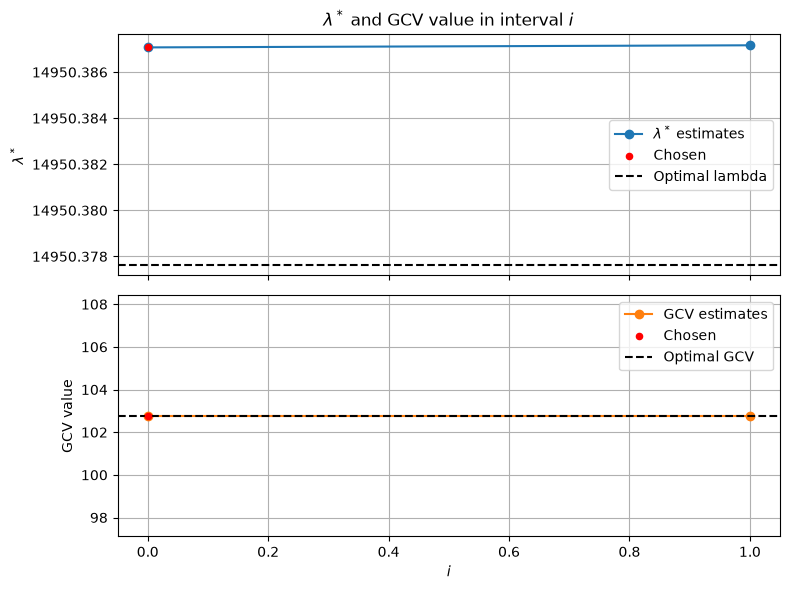

In [51]:
i = np.arange(len(interval_results))
lam_star_values = np.array([result[0] for result in interval_results])
gcv_values = np.array([result[1] for result in interval_results])

chosen_idx = np.argmin(gcv_values)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(i, lam_star_values, marker="o", label=r"$\lambda^*$ estimates")
axes[0].scatter(
    chosen_idx,
    lam_star_values[chosen_idx],
    color="red",
    s=20,
    zorder=3,
    label="Chosen"
)
axes[0].axhline(
    optimal_lambda,
    color="black",
    linestyle="--",
    label="Optimal lambda"
)
axes[0].set_ylabel(r"$\lambda^*$")
axes[0].set_title(r"$\lambda^*$ and GCV value in interval $i$")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(i, gcv_values, marker="o", color="tab:orange", label="GCV estimates")
axes[1].scatter(
    chosen_idx,
    gcv_values[chosen_idx],
    color="red",
    s=20,
    zorder=3,
    label="Chosen"
)
axes[1].axhline(
    optimal_gcv,
    color="black",
    linestyle="--",
    label="Optimal GCV"
)
axes[1].set_xlabel("$i$")
axes[1].set_ylabel("GCV value")
axes[1].legend()
axes[1].grid(True)

axes[0].ticklabel_format(axis='y', style='plain', useOffset=False)
axes[1].ticklabel_format(axis='y', style='plain', useOffset=False)

plt.tight_layout()
plt.show()

#### Showcasing the singular interval (first)

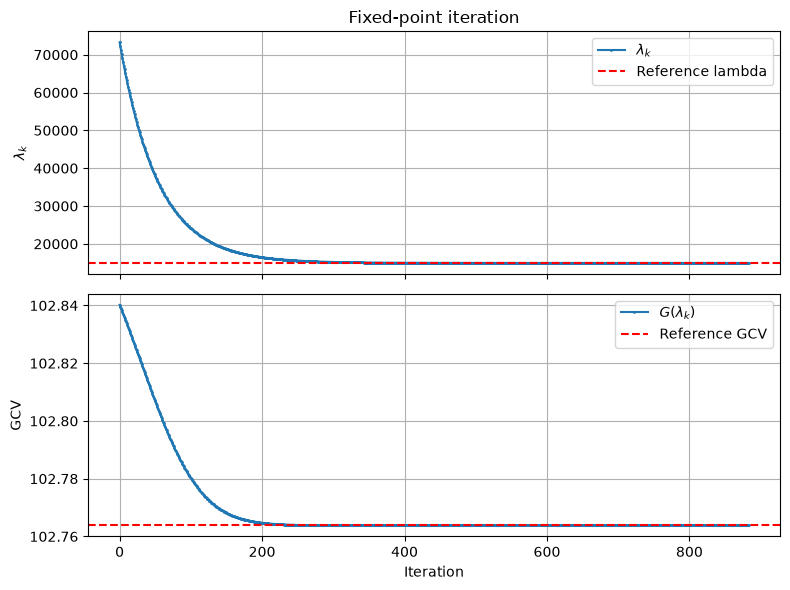

Converged: True
Final lambda: 14950.38707283052
Optimal lambda: 14950.377647753196
Final GCV: 102.7638003203922
Optimal GCV: 102.76380032039216


In [52]:
interval_index = 0

left = interval_index * 2 * r_hat
right = (interval_index + 1) * 2 * r_hat
lam_0 = (left + right) / 2

lam_star, lam_history, converged = fixed_point_iteration(lam_0, iterations = 10000)
gcv_history = [G(lam, N, a, sigma) for lam in lam_history]
iterations = np.arange(len(lam_history))

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(iterations, lam_history, marker=".", markersize = 2, label=r"$\lambda_k$")
axes[0].axhline(
    optimal_lambda, color="red", linestyle="--", label="Reference lambda"
)
axes[0].set_ylabel(r"$\lambda_k$")
axes[0].set_title("Fixed-point iteration")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(iterations, gcv_history, marker=".", markersize = 2, label=r"$G(\lambda_k)$")
axes[1].axhline(
    optimal_gcv, color="red", linestyle="--", label="Reference GCV"
)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("GCV")
axes[1].legend()
axes[1].grid(True)

axes[0].ticklabel_format(axis='y', style='plain', useOffset=False)
axes[1].ticklabel_format(axis='y', style='plain', useOffset=False)

plt.tight_layout()
plt.show()

print("Converged:", converged)
print("Final lambda:", lam_star)
print("Optimal lambda:", optimal_lambda)
print("Final GCV:", gcv_history[-1])
print("Optimal GCV:", optimal_gcv)

## Condensed test code for test cases

In [53]:
# ### Data generation
# rng = np.random.default_rng(seed=77)

# EPSILON = 10
# ASPECT_RATIO = 0.8  # aspect ratio (d/N)
# N = 1000 # observations
# D = int(ASPECT_RATIO * N)  # parameters

# theta = rng.standard_normal(size=D)[:, np.newaxis]
# theta = theta / np.linalg.norm(theta)

# covariance = spiked_covariance(D)
# X = generate_X(N, D, covariance, rng)
# y = generate_Y(X, N, theta, EPSILON, rng)

# U, sigma, Vt = np.linalg.svd(X)
# a = U.T @ y

# def G(lam, n, a, singular_values):
#     a = np.asarray(a).reshape(-1)
#     s2 = np.asarray(singular_values) ** 2
#     m = len(s2)

#     numerator = (
#         np.sum(lam**2 * a[:m]**2 / (s2 + lam)**2)
#         + np.sum(a[m:]**2)
#     ) / n

#     denominator = (1 - np.sum(s2 / (s2 + lam)) / n)**2

#     return numerator / denominator

# result = minimize_scalar(G, args=(N, a, sigma))

# print("Optimal lambda:", optimal_lambda := result.x)
# print("Optimal GCV:", optimal_gcv := result.fun)

# ### Level set
# def fprime_levelsets(lam_max, steps, n, a, singular_values):
#     def g(lam):
#         return abs(F_prime(lam, n, a, singular_values)) - 1

#     lam_grid = np.linspace(0, lam_max, steps)[1:]
#     f_values = np.array([g(lam) for lam in lam_grid])
#     roots = []

#     for i in range(len(lam_grid) - 1):
#         lam_1, lam_2 = lam_grid[i], lam_grid[i+1]
#         f_1, f_2 = f_values[i], f_values[i+1]

#         if f_1 == 0:
#             roots.append(lam_1)

#         if f_1 * f_2 < 0:
#             root = brentq(g, lam_1, lam_2)
#             roots.append(root)

#     if f_values[-1] == 0:
#         roots.append(lam_grid[-1])

#     if not roots and np.all(np.abs(f_values + 1) < 1):
#         print("The entire interval is valid.")
#         roots.extend([0.0, float(lam_max)])

#     return sorted(list(set(roots)))

# LAM_MAX = 10 * optimal_lambda
# STEPS = 10000
# print("Endpoints:", endpoints := fprime_levelsets(LAM_MAX, STEPS, N, a, sigma))
# lam_grid = np.linspace(0, LAM_MAX, 10000)[1:]
# f_values = np.array([F_prime(lam, N, a, sigma) for lam in lam_grid])

# print("Are all the values finite (T/F)?", np.all(np.isfinite(f_values)))
# print("Minimum value of F':", np.min(f_values))
# print("Maximum value of F':", np.max(f_values))

# def create_intervals(endpoints):
#   if len(endpoints) % 2 != 0:
#     raise ValueError("The list of endpoints must be even.")

#   intervals = []
#   for i in range(0, len(endpoints), 2):
#     intervals.append((endpoints[i], endpoints[i + 1]))

#   return intervals

# print(intervals := create_intervals(endpoints))

# ### Fixed-point iteration
# r = []

# for interval in intervals:
#     r_temp = (interval[1] - interval[0]) / 2
#     r.append(r_temp)

# print("R_hat:", r_hat := min(r))

# print("Number of estimated intervals:", w := int(np.ceil(LAM_MAX / (2 * r_hat))))
# def fixed_point_iteration(lam_0, iterations):
#     lam = []
#     lam.append(lam_0)
#     current_lam = lam_0

#     for i in range(iterations):
#         current_lam = F(current_lam, N, a, sigma)
#         lam.append(current_lam)

#     return current_lam, lam
    
# ### Data analysis
# for i in range(w):
#     left = i * 2 * r_hat
#     right = (i + 1) * 2 * r_hat
#     lam_0 = (left + right) / 2

#     lam_star, lam_stars = fixed_point_iteration(lam_0, iterations = 20)

# print("Estimated lambda: ", lam_star)
# print("Optimal lambda:", optimal_lambda)
# print("Difference:", lam_star - optimal_lambda)
# iterations = np.arange(len(lam_stars))

# plt.figure(figsize=(8, 4))
# plt.plot(iterations, np.asarray(lam_stars).ravel(), marker="o", label=r"$\lambda$ estimate")
# plt.axhline(optimal_lambda, color="red", linestyle="-",
#             label=r"optimal $\lambda$")
# plt.xlabel("Iteration")
# plt.ylabel(r"$\lambda$")
# plt.title(r"Fixed-point iteration for optimal $\lambda$")
# plt.legend()
# plt.grid(True)
# plt.show()